In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
import os

In [22]:
# Cargamos los csv de los tifs
path = "saved_files/dataset"
dfs = {}
for archivo in os.listdir(path):
    if archivo.endswith("_features.csv"):
        nombre_sin_extension = os.path.splitext(archivo)[0]  # sin .csv
        ruta_completa = os.path.join(path, archivo)
        dfs[nombre_sin_extension[:-9]] = pd.read_csv(ruta_completa)

Como hay algunos días y puntos concretos en los que las reflectancias son 0 y los índices por tanto se han calculado como NaN, limpiamos los datasets de esas filas:

In [23]:
for nombre_df, df in dfs.items():
    for band_set in ["rhow", "rhown"]:
        dfs[nombre_df] = df.dropna()

In [24]:
dfs["c2x-complex-nets_1x1_imida_depth_gt_1"].head(2)

,Date,Buoy,Latitude,Longitude,rhow_B1,rhow_B2,rhow_B3,rhow_B4,rhow_B5,rhow_B6,...,dif_rel_4bands_rhown_B3_B4_B5_B1,dif_rel_4bands_rhown_B3_B4_B5_B2,dif_rel_4bands_rhown_B3_B5_B4_B1,dif_rel_4bands_rhown_B3_B5_B4_B2,dif_rel_4bands_rhown_B4_B1_B5_B2,dif_rel_4bands_rhown_B4_B1_B5_B3,dif_rel_4bands_rhown_B4_B2_B5_B1,dif_rel_4bands_rhown_B4_B2_B5_B3,dif_rel_4bands_rhown_B4_B3_B5_B1,dif_rel_4bands_rhown_B4_B3_B5_B2
0,2016-08-09,CTD1,4187246,695025,0.005485,0.014069,0.038569,0.018639,0.018126,0.005038,...,-1.072,0.867,-1.200,0.971,2.315,3.081,-1.795,0.91,-2.653,-0.714
1,2016-08-09,CTD2,4181518,693105,0.007742,0.012539,0.020579,0.010966,0.010585,0.003443,...,0.562,1.055,0.611,1.146,0.606,0.935,-0.422,0.40,-0.780,-0.287


Las fórmulas que queremos comprobar son:

- $y_1 = 0.6386 e^{4.7513x}$, donde $y$ es la clorofila y $x$ es la relación de $(Green - Blue)/(Green + Blue)$

- $y_2 = 124.94x - 115.35$ donde $x = \frac{Green+NIR1}{Green + Red}$

- $y_3 = 22.835x - 12.974$ donde $x = \frac{NIR1 - NIR2}{Red - NIR2}$

- $y_4 = 32.448x - 21.408$ donde $x = \frac{NIR1}{Red}$


con las fechas


dates = [
    "28/10/2016", "20/06/2018", "07/11/2018", "14/08/2019",
    "30/06/2017", "10/07/2018", "12/03/2019", "18/09/2019",
    "20/02/2018", "29/08/2018", "25/06/2019", "03/10/2019",
    "07/03/2018", "03/10/2018"
]


Filtramos los dataframes para dejar solamente esas fechas:

In [25]:
dates = [
    "28/10/2016", "30/06/2017", "20/02/2018", "07/03/2018", "20/06/2018",
    "10/07/2018", "29/08/2018", "03/10/2018", "07/11/2018", "12/03/2019",
    "25/06/2019", "14/08/2019", "18/09/2019", "03/10/2019"
]

# De estas fechas '28/10/2016' y '18/09/2019' tienen muchas nubes y se descartaron

filter_dates = pd.to_datetime(dates, format="%d/%m/%Y")

for nombre_df, df in dfs.items():
    df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d", errors='coerce')  # asegurarse
    dfs[nombre_df] = df[df["Date"].isin(filter_dates)].copy()

Recordemos que en el paper quitan las observaciones cuya medida de Chl-a esté fuera de la mediana $\pm$ una desviación estándar. Para ello hacemos lo siguiente (no lo hacemos porque los resultados empeoran muchísimo.). De hacerlo, pasaríamos de tener 130 filas, a quedarnos solamente con 107.

In [69]:
# for nombre_df, df in dfs.items():
#     if "Chl" in df.columns:
#         mediana = df["Chl"].median()
#         desviacion = df["Chl"].std()
#         umbral_sup = mediana + desviacion
#         umbral_inf = mediana - desviacion

#         # Filtrar
#         df_filtrado = df[(df["Chl"] >= umbral_inf) & (df["Chl"] <= umbral_sup)].copy()
#         dfs[nombre_df] = df_filtrado

Definimos funciones para las fórmulas que queremos aplicar.
Recordar que:
- Blue = rhow_B2
- Green = rhow_B3
- Red = rhow_B4
- NIR1 = rhow_B5
- NIR2 = rhow_B6

In [26]:
def add_y(blue, green, red, nir1, nir2):
    x_1 = (green-blue)/(green+blue)
    y_1 = 0.6386*np.exp(4.7513*x_1)

    x_2 = (green+nir1)/(green+red)
    y_2 = 124.94*x_2 - 115.35

    x_3 = (nir1-nir2)/(red-nir2)
    y_3 = 22.835*x_3 - 12.974

    x_4 = nir1/red
    y_4 = 32.448*x_4 - 21.408

    return y_1, y_2, y_3, y_4

In [27]:
def add_y_columns_to_df(df, band_set="rhow"):
    # Mapas de bandas
    mapping = band_maps[band_set]

    # Extraer bandas desde el DataFrame
    blue = df[mapping["Blue"]]
    green = df[mapping["Green"]]
    red = df[mapping["Red"]]
    nir1 = df[mapping["NIR1"]]
    nir2 = df[mapping["NIR2"]]

    # Aplicar fórmula
    y_1, y_2, y_3, y_4 = add_y(blue, green, red, nir1, nir2)

    # Añadir columnas al DataFrame
    if band_set == "rhow":
        df["y_1_rhow"] = y_1
        df["y_2_rhow"] = y_2
        df["y_3_rhow"] = y_3
        df["y_4_rhow"] = y_4

    elif band_set == "rhown":
        df["y_1_rhown"] = y_1
        df["y_2_rhown"] = y_2
        df["y_3_rhown"] = y_3
        df["y_4_rhown"] = y_4

    return df

band_maps = {
    "rhow": {
        "Blue": "rhow_B2",
        "Green": "rhow_B3",
        "Red": "rhow_B4",
        "NIR1": "rhow_B5",
        "NIR2": "rhow_B6"
    },
    "rhown": {
        "Blue": "rhown_B2",
        "Green": "rhown_B3",
        "Red": "rhown_B4",
        "NIR1": "rhown_B5",
        "NIR2": "rhown_B6"
    }
}

In [28]:
for nombre_df, df in dfs.items():
    for band_set in ["rhow", "rhown"]:
        dfs[nombre_df] = add_y_columns_to_df(df, band_set)

In [29]:
dfs["c2x-complex-nets_1x1_upct_depth_eq_0"]

,Date,Buoy,Latitude,Longitude,rhow_B1,rhow_B2,rhow_B3,rhow_B4,rhow_B5,rhow_B6,...,dif_rel_4bands_rhown_B4_B3_B5_B1,dif_rel_4bands_rhown_B4_B3_B5_B2,y_1_rhow,y_2_rhow,y_3_rhow,y_4_rhow,y_1_rhown,y_2_rhown,y_3_rhown,y_4_rhown
0,2017-06-30,CTD1,4187246,695025,0.017563,0.029990,0.048420,0.014543,0.010372,0.002755,...,-0.300,-0.049,1.950846,1.313153,1.781389,1.733785,1.957004,1.503004,2.005646,1.919902
1,2017-06-30,CTD2,4181518,693105,0.004140,0.010239,0.015845,0.003232,0.001904,0.000497,...,-0.289,0.009,1.773041,0.895752,-1.224828,-2.288050,1.671335,1.956958,-0.016222,-0.854933
2,2017-06-30,CTD3,4181698,695238,0.027345,0.035083,0.045390,0.014856,0.011023,0.002955,...,-0.077,0.017,1.173558,1.639837,2.505760,2.666935,1.192452,1.268809,2.161340,2.176734
3,2017-06-30,CTD4,4180266,698264,0.016332,0.026202,0.042141,0.014357,0.010686,0.002870,...,-0.318,-0.066,1.934013,1.470904,2.562449,2.742413,1.944925,1.383317,2.508287,2.621199
4,2017-06-30,CTD6,4176009,695829,0.026543,0.036842,0.052834,0.016880,0.012582,0.003304,...,-0.152,-0.017,1.490107,1.886678,2.631243,2.777441,1.517894,1.440752,2.233884,2.231587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,2019-10-03,CTD7,4176724,690397,0.005343,0.011023,0.021002,0.007354,0.005184,0.001425,...,-0.657,-0.134,2.806838,0.029888,1.503320,1.466066,2.797914,0.783779,2.151150,2.197001
156,2019-10-03,CTD8,4174178,693048,0.004528,0.008652,0.015074,0.004986,0.003832,0.001091,...,-0.517,-0.116,2.310333,2.400557,3.093476,3.528193,2.337666,2.501387,3.168702,3.634263
157,2019-10-03,CTD10,4170388,695646,0.001122,0.003448,0.012219,0.007572,0.005957,0.001702,...,-4.571,-1.077,9.128051,-0.599985,3.581198,4.122677,9.089407,-0.300673,3.588442,4.202476
158,2019-10-03,CTD11,4169609,700351,0.005645,0.009708,0.016644,0.008385,0.006649,0.002074,...,-0.701,-0.203,2.230126,0.923938,3.579497,4.321916,2.252255,1.944595,4.302911,5.083915


In [39]:
dfs["c2x-complex-nets_1x1_imida_depth_eq_0"][["Date","Chl", "y_2_rhow","y_3_rhow"]]

,Date,Chl,y_2_rhow,y_3_rhow
19,2017-06-30,1.04,1.313153,1.781389
20,2017-06-30,0.46,0.895752,-1.224828
21,2017-06-30,1.24,1.639837,2.505760
22,2017-06-30,1.05,1.470904,2.562449
23,2017-06-30,1.33,1.886678,2.631243
...,...,...,...,...
153,2019-10-03,7.17,0.029888,1.503320
154,2019-10-03,4.44,2.400557,3.093476
155,2019-10-03,6.66,-0.599985,3.581198
156,2019-10-03,4.13,0.923938,3.579497


In [31]:
metrics_df = pd.DataFrame()
for nombre_df, df in dfs.items():
    
    # R2 (coeficiente de determinación)
    try:
        metrics_df.loc[nombre_df, "r2_y_1_rhow"] = r2_score(df["Chl"], df["y_1_rhow"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_2_rhow"] = r2_score(df["Chl"], df["y_2_rhow"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_3_rhow"] = r2_score(df["Chl"], df["y_3_rhow"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_4_rhow"] = r2_score(df["Chl"], df["y_4_rhow"]).round(3)
    except:
        continue

    try:
        metrics_df.loc[nombre_df, "r2_y_1_rhown"] = r2_score(df["Chl"], df["y_1_rhown"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_2_rhown"] = r2_score(df["Chl"], df["y_2_rhown"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_3_rhown"] = r2_score(df["Chl"], df["y_3_rhown"]).round(3)
        metrics_df.loc[nombre_df, "r2_y_4_rhown"] = r2_score(df["Chl"], df["y_4_rhown"]).round(3)
    except:
        continue

    # Coeficiente de correlación (correlación lineal)
    # try:
    #     metrics_df.loc[nombre_df, "corr_y_1_rhow"] = df["Chl"].corr(df["y_1_rhow"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_2_rhow"] = df["Chl"].corr(df["y_2_rhow"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_3_rhow"] = df["Chl"].corr(df["y_3_rhow"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_4_rhow"] = df["Chl"].corr(df["y_4_rhow"]).round(3)
    # except:
    #     continue

    # try:
    #     metrics_df.loc[nombre_df, "corr_y_1_rhown"] = df["Chl"].corr(df["y_1_rhown"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_2_rhown"] = df["Chl"].corr(df["y_2_rhown"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_3_rhown"] = df["Chl"].corr(df["y_3_rhown"]).round(3)
    #     metrics_df.loc[nombre_df, "corr_y_4_rhown"] = df["Chl"].corr(df["y_4_rhown"]).round(3)
    # except:
    #     continue

    # RMSE
    # try:
    # metrics_df.loc[nombre_df, "rmse_y_1_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_1_rhow"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_2_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_2_rhow"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_3_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_3_rhow"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_4_rhow"] = np.sqrt(mean_squared_error(df["Chl"], df["y_4_rhow"])).round(3)
    # except:
    # continue

    # try:
    # metrics_df.loc[nombre_df, "rmse_y_1_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_1_rhown"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_2_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_2_rhown"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_3_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_3_rhown"])).round(3)
    # metrics_df.loc[nombre_df, "rmse_y_4_rhown"] = np.sqrt(mean_squared_error(df["Chl"], df["y_4_rhown"])).round(3)
    # except:
    # continue

    # #NRMSE
    # try:
    # metrics_df.loc[nombre_df, "nrmse_y_1_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_1_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # metrics_df.loc[nombre_df, "nrmse_y_2_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_2_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # metrics_df.loc[nombre_df, "nrmse_y_3_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_3_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # metrics_df.loc[nombre_df, "nrmse_y_4_rhow"] = (metrics_df.loc[nombre_df, "rmse_y_4_rhow"]/(df["Chl"].max()-df["Chl"].min())).round(3)*100
    # except:
    # continue

In [38]:
metrics_df.sort_values(by=["r2_y_2_rhow"], ascending=False)

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_1_rhown,r2_y_2_rhown,r2_y_3_rhown,r2_y_4_rhown
c2x-complex-nets_9x9_imida_depth_gt_1,0.246,-0.760,-0.665,-1.158,0.245,-0.495,-0.215,-0.460
c2x-nets_9x9_imida_depth_gt_1,0.246,-0.760,-0.665,-1.158,0.245,-0.495,-0.215,-0.460
c2x-nets_5x5_imida_depth_gt_1,0.177,-0.810,-0.650,-1.170,0.174,-0.491,-0.157,-0.405
c2x-complex-nets_5x5_imida_depth_gt_1,0.177,-0.810,-0.650,-1.170,0.174,-0.491,-0.157,-0.405
c2x-nets_9x9_imida_depth_eq_1,0.322,-0.845,-0.736,-1.347,0.326,-0.565,-0.226,-0.530
...,...,...,...,...,...,...,...,...
c2x-nets_5x5_upct_depth_eq_0,-27.937,-18.114,-21.546,-31.991,-27.045,-21.551,-20.751,-26.281
c2x-complex-nets_3x3_upct_depth_eq_0,-29.312,-24.574,-27.027,-38.877,-28.120,-25.700,-23.142,-29.793
c2x-nets_3x3_upct_depth_eq_0,-29.312,-24.574,-27.027,-38.877,-28.120,-25.700,-23.142,-29.793
c2x-complex-nets_1x1_upct_depth_eq_0,-34.023,-27.256,-32.571,-46.555,-31.707,-29.342,-29.407,-37.223


In [35]:
filtered_df = metrics_df.loc[metrics_df.index.str.contains("imida")]
filtered_df[filtered_df.gt(0.6).any(axis=1)]

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_1_rhown,r2_y_2_rhown,r2_y_3_rhown,r2_y_4_rhown


In [36]:
filtered_df = metrics_df.loc[metrics_df.index.str.contains("upct")]
filtered_df[filtered_df.gt(0.6).any(axis=1)]

,r2_y_1_rhow,r2_y_2_rhow,r2_y_3_rhow,r2_y_4_rhow,r2_y_1_rhown,r2_y_2_rhown,r2_y_3_rhown,r2_y_4_rhown


In [40]:
from sklearn.linear_model import LinearRegression

df = dfs["c2x-nets_3x3_upct_depth_lt_1"][["y_1_rhow", "y_2_rhow","y_3_rhow","y_4_rhow","Chl"]]
X = df[["y_1_rhow", "y_2_rhow","y_3_rhow","y_4_rhow"]]
y = df["Chl"]

model = LinearRegression().fit(X, y)
pred = model.predict(X)

r2 = r2_score(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
nrmse = rmse / (np.max(y)- np.min(y)) * 100
print('RMSE: %.3f' % rmse)
print('R squared: %.3f' % r2)
print(f"NRMSE: {nrmse:.1f}%")

RMSE: 0.533
R squared: 0.479
NRMSE: 15.8%


### Scatter plots

In [ ]:
filtered_df[filtered_df.gt(0.7).any(axis=1)]

In [16]:
def plot_chl_vs_x_rhow(df, nombre_df):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

    # Bandas necesarias
    blue = df["rhow_B2"]
    green = df["rhow_B3"]
    red = df["rhow_B4"]
    nir1 = df["rhow_B5"]
    nir2 = df["rhow_B6"]
    chl = df["Chl"]

    # Calcular x_i y modelos teóricos
    x1 = (green - blue) / (green + blue)
    y1 = 0.6386 * np.exp(4.7513 * x1)

    x2 = (green + nir1) / (green + red)
    y2 = 124.94 * x2 - 115.35

    x3 = (nir1 - nir2) / (red - nir2)
    y3 = 22.835 * x3 - 12.974

    x4 = nir1 / red
    y4 = 32.448 * x4 - 21.408

    x_all = [x1, x2, x3, x4]
    y_all = [y1, y2, y3, y4]
    titles = ["x1 = (G-B)/(G+B)", "x2 = (G+NIR1)/(G+R)", "x3 = (NIR1-NIR2)/(R-NIR2)", "x4 = NIR1/R"]

    for i in range(4):
        ax = axes[i]
        ax.scatter(x_all[i], chl, alpha=0.5, label="Chl vs x")
        # Ordenar para trazar la línea del modelo de forma continua
        x_sorted = np.sort(x_all[i])
        y_sorted = np.sort(y_all[i])  # opcional: puedes usar y_all[i][x_all[i].argsort()]
        ax.plot(x_sorted, y_sorted, 'r-', label="Modelo teórico")
        ax.set_xlabel(f"x{i+1}")
        ax.set_ylabel("Chl")
        ax.set_title(titles[i])
        ax.grid(True)
        ax.legend()

    fig.suptitle(f"Relación Chl vs x_i (rhow) - {nombre_df}")
    plt.tight_layout()
    plt.show()



In [17]:
my_df = dfs["c2x-nets_3x3_imida_depth_eq_0"]
my_df.loc[my_df["Chl"]>17,:][["Date","Buoy","Chl", "y_2_rhow", "y_3_rhow"]]

,Date,Buoy,Chl,y_2_rhow,y_3_rhow


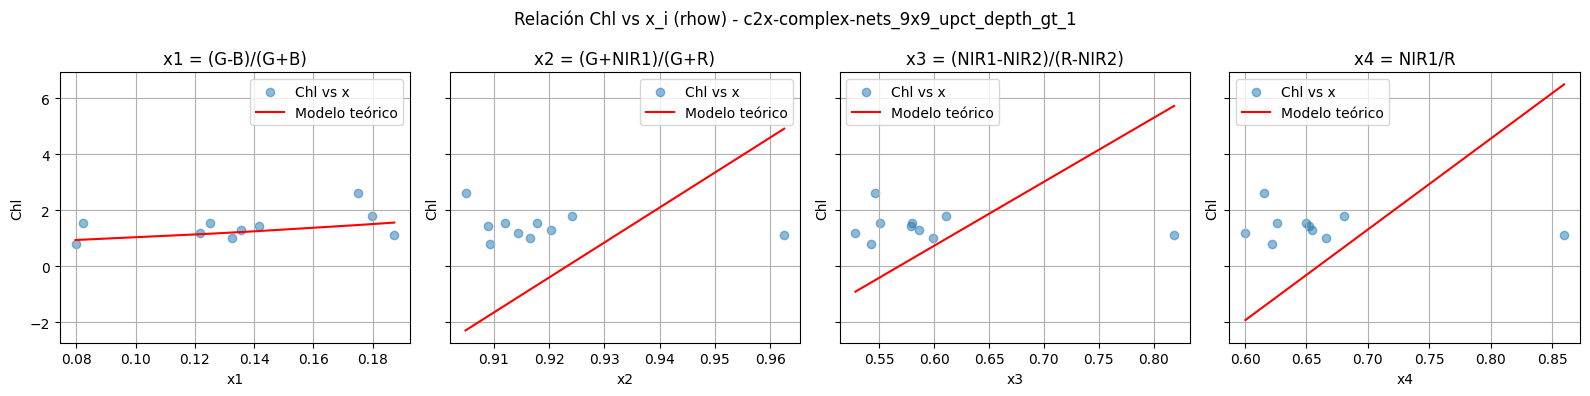

In [117]:
nombres_a_graficar = filtered_df[filtered_df.gt(0.0).any(axis=1)].index
for nombre_df in nombres_a_graficar:
    if nombre_df in dfs:
        df = dfs[nombre_df]
        columnas_necesarias = ["Chl", "rhow_B2", "rhow_B3", "rhow_B4", "rhow_B5", "rhow_B6"]
        if all(col in df.columns for col in columnas_necesarias):
            plot_chl_vs_x_rhow(df, nombre_df)

